<a href="https://colab.research.google.com/github/shahedkollol/CSE428_project_Oxford-IITDATA_SET/blob/main/23101263_SHAHED_PARVES_KALLOL_Assignment02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Assignment 2

Max collaborators = 3

Hand holding is low for this assignment. Adjust accordingly. In case of confusion, feel free to reach out to your lab faculties. Good luck.

In [4]:
COLLABORATORS_NAME = "SHAHED PARVES KALLOL"
COLLABORATORS_ID = "23101263"

#Loading dependencies

In [12]:
import numpy as np
from tensorflow import keras
import sklearn
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings('ignore')

#Loading dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [5]:
import numpy as np
import sklearn

# Path to the dataset in Google Drive
dataset_path = '/content/drive/MyDrive/CSE428/Assignment02/cifar-10.npz'
# Load the dataset from the .npz file
data = np.load(dataset_path)
x_train_raw = data['x_train']
y_train_raw = data['y_train'].reshape(-1, 1)
x_test_raw = data['x_test']
y_test_raw = data['y_test'].reshape(-1, 1)

# Resample data using COLLABORATORS_ID
x_train, y_train = sklearn.utils.resample(x_train_raw, y_train_raw, replace = False, n_samples = 5000, random_state = int(COLLABORATORS_ID), stratify = y_train_raw)
x_test, y_test = sklearn.utils.resample(x_test_raw, y_test_raw, replace = False, n_samples = 1000, random_state = int(COLLABORATORS_ID), stratify = y_test_raw)

In [18]:
CLASS_NAMES = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

print('x_train shape:', x_train.shape)
print('y_train shape:', y_train.shape)
print('x_test shape :', x_test.shape)
print('y_test shape :', y_test.shape)

x_train shape: (5000, 32, 32, 3)
y_train shape: (5000, 1)
x_test shape : (1000, 32, 32, 3)
y_test shape : (1000, 1)


#Task 1: Training a logistic regressor [10 Marks]

###1. Convert the images to grayscale

Grayscale train shape: (5000, 32, 32)
Grayscale test  shape: (1000, 32, 32)


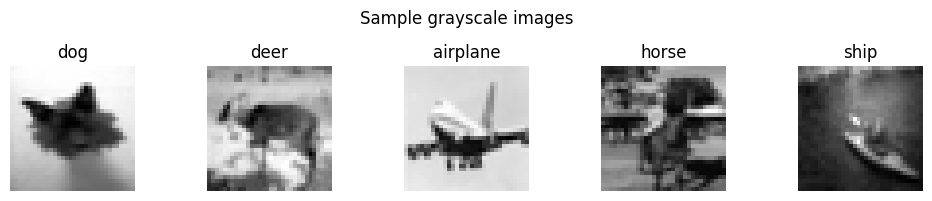

In [13]:
# Convert RGB images to grayscale using the luminosity formula
# Y = 0.2989*R + 0.5870*G + 0.1140*B
def rgb_to_grayscale(images):
    """Convert a batch of RGB images (N, H, W, 3) to grayscale (N, H, W)."""
    weights = np.array([0.2989, 0.5870, 0.1140], dtype=np.float32)
    return np.dot(images.astype(np.float32), weights)

x_train_gray = rgb_to_grayscale(x_train)  # shape: (5000, 32, 32)
x_test_gray  = rgb_to_grayscale(x_test)   # shape: (1000, 32, 32)

print('Grayscale train shape:', x_train_gray.shape)
print('Grayscale test  shape:', x_test_gray.shape)

# Quick visual check
fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i, ax in enumerate(axes):
    ax.imshow(x_train_gray[i], cmap='gray')
    ax.set_title(CLASS_NAMES[int(y_train[i])])
    ax.axis('off')
plt.suptitle('Sample grayscale images')
plt.tight_layout()
plt.show()

### 2. Prepare the grayscale images for logistic regressor (reshape and normalize)

Use z-score normalization.

In [14]:
# Flatten 32x32 images to 1024-dim vectors
x_train_flat = x_train_gray.reshape(len(x_train_gray), -1)  # (5000, 1024)
x_test_flat  = x_test_gray.reshape(len(x_test_gray), -1)    # (1000, 1024)

# Z-score normalization: fit scaler on training data only, apply to both
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_flat)
x_test_scaled  = scaler.transform(x_test_flat)

# Flatten label arrays from (N,1) to (N,)
y_train_flat = y_train.ravel()
y_test_flat  = y_test.ravel()

print('Scaled train shape:', x_train_scaled.shape)
print('Train mean (should be ~0):', x_train_scaled.mean().round(4))
print('Train std  (should be ~1):', x_train_scaled.std().round(4))

Scaled train shape: (5000, 1024)
Train mean (should be ~0): -0.0
Train std  (should be ~1): 1.0


###3. Create a validation set (20%)

In [15]:
# Stratify ensures each class is proportionally rep
x_tr, x_val, y_tr, y_val = train_test_split(
    x_train_scaled, y_train_flat,
    test_size=0.20,
    random_state=42,
    stratify=y_train_flat
)

print(f'Training samples  : {len(x_tr)}')
print(f'Validation samples: {len(x_val)}')
print(f'Test samples      : {len(x_test_scaled)}')

Training samples  : 4000
Validation samples: 1000
Test samples      : 1000


###4. Compute class weights

Go through this link - https://scikit-learn.org/stable/modules/generated/sklearn.utils.class_weight.compute_class_weight.html

In [16]:
# compute_class_weight returns an array of weights in class order
classes = np.unique(y_tr)
weights_array = compute_class_weight(class_weight='balanced',classes=classes,y=y_tr)

# Converting dict {class_label: weight} for sklearn
class_weight_dict = dict(zip(classes, weights_array))

print('Class weights:')
for cls, w in class_weight_dict.items():
    print(f'  Class {cls:2d} ({CLASS_NAMES[cls]:12s}): {w:.4f}')

Class weights:
  Class  0 (airplane    ): 1.0000
  Class  1 (automobile  ): 1.0000
  Class  2 (bird        ): 1.0000
  Class  3 (cat         ): 1.0000
  Class  4 (deer        ): 1.0000
  Class  5 (dog         ): 1.0000
  Class  6 (frog        ): 1.0000
  Class  7 (horse       ): 1.0000
  Class  8 (ship        ): 1.0000
  Class  9 (truck       ): 1.0000


###5. Run the logistic regressor

Use L2 regularizer. Find the C hyperparameter value through grid search. Pick the testing values according to your understanding. Use at least 3 test values and at max 5. Use the computed class weights while training your model.

In [17]:
# C is the inverse of regularization strength:
# smaller C = stronger regularization
# We test 4 values spanning a log scale
param_grid = {'C': [0.01, 0.1, 1.0, 10.0]}

base_lr = LogisticRegression(
    penalty='l2',
    solver='lbfgs',
    multi_class='multinomial',
    max_iter=1000,
    class_weight=class_weight_dict,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=base_lr,
    param_grid=param_grid,
    cv=3,# 3-fold CV on the training split
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(x_tr, y_tr)

print('\nGrid search results:')
for mean, std, params in zip(
    grid_search.cv_results_['mean_test_score'],
    grid_search.cv_results_['std_test_score'],
    grid_search.cv_results_['params']
):
    print(f'  C={params["C"]:6.3f}  -> val accuracy: {mean:.4f} ± {std:.4f}')

best_C = grid_search.best_params_['C']
print(f'\nBest C: {best_C}')

# Retrieving best estimator(already on x_tr)
best_lr = grid_search.best_estimator_

# Validation accuracy
val_acc = accuracy_score(y_val, best_lr.predict(x_val))
print(f'Validation accuracy with best C: {val_acc:.4f}')

Fitting 3 folds for each of 4 candidates, totalling 12 fits

Grid search results:
  C= 0.010  -> val accuracy: 0.2508 ± 0.0024
  C= 0.100  -> val accuracy: 0.2083 ± 0.0029
  C= 1.000  -> val accuracy: 0.1898 ± 0.0064
  C=10.000  -> val accuracy: 0.1828 ± 0.0108

Best C: 0.01
Validation accuracy with best C: 0.2740


###6. Evaluate the logistic regressor on the test set

In [ ]:
y_pred_lr = best_lr.predict(x_test_scaled)
test_acc = accuracy_score(y_test_flat, y_pred_lr)
print(f'Logistic Regression Test Accuracy: {test_acc:.4f}\n')

print('Classification Report:')
print(classification_report(y_test_flat, y_pred_lr, target_names=CLASS_NAMES))

Logistic Regression Test Accuracy: 0.2340

Classification Report:
              precision    recall  f1-score   support

    airplane       0.26      0.25      0.26       100
  automobile       0.31      0.30      0.30       100
        bird       0.25      0.27      0.26       100
         cat       0.15      0.14      0.14       100
        deer       0.20      0.18      0.19       100
         dog       0.16      0.16      0.16       100
        frog       0.18      0.17      0.17       100
       horse       0.25      0.21      0.23       100
        ship       0.28      0.34      0.31       100
       truck       0.28      0.32      0.30       100

    accuracy                           0.23      1000
   macro avg       0.23      0.23      0.23      1000
weighted avg       0.23      0.23      0.23      1000



###7. Write code to pick up a random image from the test set and display it

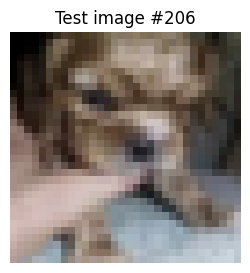

Chosen index: 206


In [26]:
# Pick a random index from the test
 # fresh random each run
rng = np.random.default_rng(seed=None)
rand_idx = rng.integers(0, len(x_test))

plt.figure(figsize=(3, 3))
plt.imshow(x_test[rand_idx])
plt.title(f'Test image #{rand_idx}')
plt.axis('off')
plt.show()

print(f'Chosen index: {rand_idx}')

###8. Print the predicted class vs the original class

Do not print out the numerical class. Map it from here - https://keras.io/2/api/datasets/cifar10/

In [27]:
# Predict for the randomly chosen image
sample_scaled = x_test_scaled[rand_idx].reshape(1, -1)
pred_label_lr = int(best_lr.predict(sample_scaled)[0])
true_label    = int(y_test_flat[rand_idx])

print(f'Predicted class : {CLASS_NAMES[pred_label_lr]}')
print(f'Actual class    : {CLASS_NAMES[true_label]}')
print('Correct!' if pred_label_lr == true_label else 'Incorrect.')

Predicted class : frog
Actual class    : dog
Incorrect.


#Task 2: Training a convolutional neural network [20 Marks]

We will not strictly control how you implement this code. You can use either Tensorflow or PyTorch. However the structure of the network must be -

```
Input -> Conv1 -> Conv2 -> Conv3 -> Fully Connected 1 -> Fully Connected 2 -> Output
```

Use activation functions and pooling as you want. Feel free to adjust dimensions as you need. Set the hyperparameters yourself. Use a maximum learning rate of 0.01 and a maximum epoch number of 100. Use AdamW as optimizer.

**Try achieving good accuracy. There are marks for that.**

###1. Train the model on grayscale images

You do not need to use the validation set. Train on the initial train set. Recalculate the class weights again and pass it to the optimizer function. Normalize the images before processing.

In [ ]:
#Helper: build the CNN
def build_cnn(input_shape, num_classes=10, extra_conv=False):

    """Input→ Conv1 → Conv2 → Conv3 [→ Conv4 if extra_conv]→ FC1→FC2→Output
    BatchNorm after each conv to stabilise training on small dataset.
    MaxPool after Conv2 and Conv3 (and Conv4) to reduce spatial dimensions.
    Dropout before FC1 to reduce overfitting.
    """
    inputs = layers.Input(shape=input_shape)

    # Conv Block 1
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)

    # Conv Block 2
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)    # 32x32 -> 16x16

    # Conv Block 3
    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)    # 16x16 -> 8x8

    # Optional Conv Block 4
    if extra_conv:
        x = layers.Conv2D(256, (3, 3), padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D(pool_size=(2, 2))(x)  # 8x8 -> 4x4

    # Flatten+ Fully Connected layers
    x = layers.Flatten()(x)
    x = layers.Dropout(0.4)(x)

    # FC1
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)

    # FC2 / Output
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    return model


#grayscale data
# Normalize and add channel dim for Conv2D
x_train_gray_norm = (x_train_gray / 255.0)[..., np.newaxis]
x_test_gray_norm  = (x_test_gray  / 255.0)[..., np.newaxis]

# One-hot encode labels
y_train_ohe = keras.utils.to_categorical(y_train_flat, num_classes=10)
y_test_ohe  = keras.utils.to_categorical(y_test_flat,  num_classes=10)

# Recompute class weights on the full training set
cnn_classes = np.unique(y_train_flat)
cnn_weights_array = compute_class_weight(
    class_weight='balanced', classes=cnn_classes, y=y_train_flat
)
cnn_class_weight = dict(zip(cnn_classes.tolist(), cnn_weights_array.tolist()))
print('CNN class weights:', {CLASS_NAMES[k]: round(v, 3) for k, v in cnn_class_weight.items()})

cnn_gray = build_cnn(input_shape=(32, 32, 1))
cnn_gray.compile(
    optimizer=AdamW(learning_rate=0.001, weight_decay=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
cnn_gray.summary()


# Train
early_stop = EarlyStopping(
    monitor='val_loss', patience=10,
    restore_best_weights=True, verbose=1
)

history_gray = cnn_gray.fit(
    x_train_gray_norm, y_train_ohe,
    batch_size=64,
    epochs=100,
    validation_split=0.1,     # small internal val to monitor convergence
    class_weight=cnn_class_weight,
    callbacks=[early_stop],
    verbose=1
)

# Training curve
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_gray.history['accuracy'],     label='train')
axes[0].plot(history_gray.history['val_accuracy'], label='val')
axes[0].set_title('Grayscale CNN — Accuracy')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history_gray.history['loss'],     label='train')
axes[1].plot(history_gray.history['val_loss'], label='val')
axes[1].set_title('Grayscale CNN — Loss')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

CNN class weights: {'airplane': 1.0, 'automobile': 1.0, 'bird': 1.0, 'cat': 1.0, 'deer': 1.0, 'dog': 1.0, 'frog': 1.0, 'horse': 1.0, 'ship': 1.0, 'truck': 1.0}


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,194,570 (8.37 MB)

 Trainable params: 2,193,610 (8.37 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 50s 649ms/step - accuracy: 0.3196 - loss: 2.2165 - val_accuracy: 0.0700 - val_loss: 4.7675
Epoch 2/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 48s 679ms/step - accuracy: 0.4951 - loss: 1.4908 - val_accuracy: 0.0820 - val_loss: 6.9071
Epoch 3/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.5976 - loss: 1.1783 - val_accuracy: 0.0980 - val_loss: 5.2456
Epoch 4/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 49s 695ms/step - accuracy: 0.6831 - loss: 0.9407 - val_accuracy: 0.1160 - val_loss: 5.9283
Epoch 5/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 48s 680ms/step - accuracy: 0.7420 - loss: 0.7449 - val_accuracy: 0.0980 - val_loss: 6.3308
Epoch 6/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 48s 682ms/step - accuracy: 0.8036 - loss: 0.5695 - val_accuracy: 0.1020 - val_loss: 7.5341
Epoch 7/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 46s 655ms/step - accuracy: 0.8651 - loss: 0.4232 - val_accuracy: 0.1760 - val_loss: 4.0910
Epoch 8/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 93s 819ms/step - accuracy: 0.9080 - loss: 0.3103 - val

###2. Evaluate the model on the grayscale test set

In [ ]:
loss_gray, acc_gray = cnn_gray.evaluate(x_test_gray_norm, y_test_ohe, verbose=0)
print(f'Grayscale CNN — Test Loss    : {loss_gray:.4f}')
print(f'Grayscale CNN — Test Accuracy: {acc_gray:.4f}\n')

y_pred_gray = np.argmax(cnn_gray.predict(x_test_gray_norm), axis=1)
print('Classification Report (Grayscale CNN):')
print(classification_report(y_test_flat, y_pred_gray, target_names=CLASS_NAMES))

Grayscale CNN — Test Loss    : 1.4507
Grayscale CNN — Test Accuracy: 0.5490

32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step
Classification Report (Grayscale CNN):
              precision    recall  f1-score   support

    airplane       0.70      0.58      0.63       100
  automobile       0.78      0.73      0.75       100
        bird       0.39      0.38      0.38       100
         cat       0.27      0.42      0.33       100
        deer       0.42      0.53      0.47       100
         dog       0.40      0.44      0.42       100
        frog       0.71      0.59      0.64       100
       horse       0.66      0.60      0.63       100
        ship       0.74      0.63      0.68       100
       truck       0.79      0.59      0.67       100

    accuracy                           0.55      1000
   macro avg       0.59      0.55      0.56      1000
weighted avg       0.59      0.55      0.56      1000



###3. Write code to pick up a random image from the test set and display it

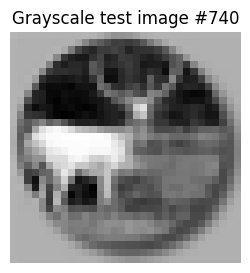

Chosen index: 740


In [ ]:
rand_idx_cnn = np.random.randint(0, len(x_test))

plt.figure(figsize=(3, 3))
plt.imshow(x_test_gray[rand_idx_cnn], cmap='gray')
plt.title(f'Grayscale test image #{rand_idx_cnn}')
plt.axis('off')
plt.show()

print(f'Chosen index: {rand_idx_cnn}')

###4. Print the predicted class vs the original class

In [ ]:
sample_gray = x_test_gray_norm[rand_idx_cnn][np.newaxis, ...]  # (1, 32, 32, 1)
pred_gray_cnn = int(np.argmax(cnn_gray.predict(sample_gray), axis=1)[0])
true_gray     = int(y_test_flat[rand_idx_cnn])

print(f'Predicted class : {CLASS_NAMES[pred_gray_cnn]}')
print(f'Actual class    : {CLASS_NAMES[true_gray]}')
print('Correct!' if pred_gray_cnn == true_gray else 'Incorrect.')

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 545ms/step
Predicted class : automobile
Actual class    : deer
Incorrect.


###5. Train the model on the RGB images

Keep the model same.

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,195,146 (8.37 MB)

 Trainable params: 2,194,186 (8.37 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 13s 79ms/step - accuracy: 0.3560 - loss: 2.0842 - val_accuracy: 0.1360 - val_loss: 3.5291
Epoch 2/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5076 - loss: 1.4401 - val_accuracy: 0.1400 - val_loss: 4.0682
Epoch 3/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5982 - loss: 1.1755 - val_accuracy: 0.1360 - val_loss: 3.6827
Epoch 4/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6716 - loss: 0.9384 - val_accuracy: 0.2020 - val_loss: 3.8064
Epoch 5/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7436 - loss: 0.7381 - val_accuracy: 0.2080 - val_loss: 3.4459
Epoch 6/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7820 - loss: 0.6316 - val_accuracy: 0.2780 - val_loss: 2.9704
Epoch 7/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8424 - loss: 0.4726 - val_accuracy: 0.4200 - val_loss: 1.9622
Epoch 8/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8836 - loss: 0.3641 - val_accuracy: 0

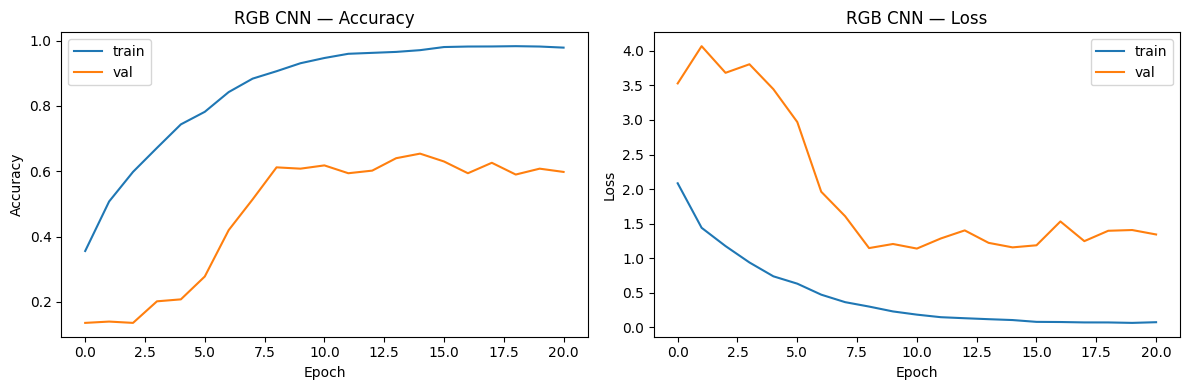

In [ ]:
# Normalize RGB images
x_train_rgb_norm = x_train.astype(np.float32) / 255.0  # (5000, 32, 32, 3)
x_test_rgb_norm  = x_test.astype(np.float32)  / 255.0  # (1000, 32, 32, 3)

#same architecture with 3 input channels
cnn_rgb = build_cnn(input_shape=(32, 32, 3))
cnn_rgb.compile(
    optimizer=AdamW(learning_rate=0.001, weight_decay=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
cnn_rgb.summary()

# Train
history_rgb = cnn_rgb.fit(
    x_train_rgb_norm, y_train_ohe,
    batch_size=64,
    epochs=100,
    validation_split=0.1,
    class_weight=cnn_class_weight,
    callbacks=[EarlyStopping(
        monitor='val_loss', patience=10,
        restore_best_weights=True, verbose=1
    )],
    verbose=1
)

# Training curve
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_rgb.history['accuracy'],     label='train')
axes[0].plot(history_rgb.history['val_accuracy'], label='val')
axes[0].set_title('RGB CNN — Accuracy')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history_rgb.history['loss'],     label='train')
axes[1].plot(history_rgb.history['val_loss'], label='val')
axes[1].set_title('RGB CNN — Loss')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

###6. Evaluate the model on the RGB images

In [ ]:
loss_rgb, acc_rgb = cnn_rgb.evaluate(x_test_rgb_norm, y_test_ohe, verbose=0)
print(f'RGB CNN — Test Loss    : {loss_rgb:.4f}')
print(f'RGB CNN — Test Accuracy: {acc_rgb:.4f}\n')

y_pred_rgb = np.argmax(cnn_rgb.predict(x_test_rgb_norm), axis=1)
print('Classification Report (RGB CNN):')
print(classification_report(y_test_flat, y_pred_rgb, target_names=CLASS_NAMES))

RGB CNN — Test Loss    : 1.2463
RGB CNN — Test Accuracy: 0.5920

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
Classification Report (RGB CNN):
              precision    recall  f1-score   support

    airplane       0.61      0.75      0.68       100
  automobile       0.66      0.72      0.69       100
        bird       0.51      0.37      0.43       100
         cat       0.38      0.42      0.40       100
        deer       0.47      0.54      0.50       100
         dog       0.45      0.52      0.48       100
        frog       0.80      0.57      0.67       100
       horse       0.72      0.65      0.68       100
        ship       0.73      0.71      0.72       100
       truck       0.68      0.67      0.68       100

    accuracy                           0.59      1000
   macro avg       0.60      0.59      0.59      1000
weighted avg       0.60      0.59      0.59      1000



###7. Write code to pick up a random image from the test set and display it

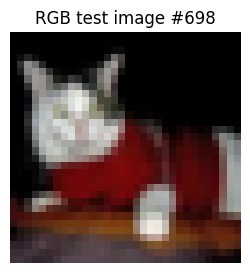

Chosen index: 698


In [ ]:
rand_idx_rgb = np.random.randint(0, len(x_test))

plt.figure(figsize=(3, 3))
plt.imshow(x_test[rand_idx_rgb])
plt.title(f'RGB test image #{rand_idx_rgb}')
plt.axis('off')
plt.show()

print(f'Chosen index: {rand_idx_rgb}')

###8. Print the predicted class vs the original class

In [ ]:
sample_rgb = x_test_rgb_norm[rand_idx_rgb][np.newaxis, ...]  # (1, 32, 32, 3)
pred_rgb_cnn = int(np.argmax(cnn_rgb.predict(sample_rgb), axis=1)[0])
true_rgb     = int(y_test_flat[rand_idx_rgb])

print(f'Predicted class : {CLASS_NAMES[pred_rgb_cnn]}')
print(f'Actual class    : {CLASS_NAMES[true_rgb]}')
print('Correct!' if pred_rgb_cnn == true_rgb else 'Incorrect.')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step
Predicted class : cat
Actual class    : cat
Correct!


###9. Add one more conv layer and check if it increases the performance for the RGB images

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,442,762 (5.50 MB)

 Trainable params: 1,441,290 (5.50 MB)

 Non-trainable params: 1,472 (5.75 KB)

Epoch 1/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 19s 115ms/step - accuracy: 0.3278 - loss: 2.1428 - val_accuracy: 0.0940 - val_loss: 3.0665
Epoch 2/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4742 - loss: 1.5188 - val_accuracy: 0.1840 - val_loss: 2.6822
Epoch 3/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5591 - loss: 1.2537 - val_accuracy: 0.1060 - val_loss: 3.4953
Epoch 4/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6309 - loss: 1.0472 - val_accuracy: 0.1100 - val_loss: 4.1215
Epoch 5/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6718 - loss: 0.9534 - val_accuracy: 0.2560 - val_loss: 3.4471
Epoch 6/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7044 - loss: 0.8221 - val_accuracy: 0.3500 - val_loss: 1.9849
Epoch 7/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7876 - loss: 0.6037 - val_accuracy: 0.4120 - val_loss: 1.7078
Epoch 8/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8407 - loss: 0.4810 - val_accuracy: 

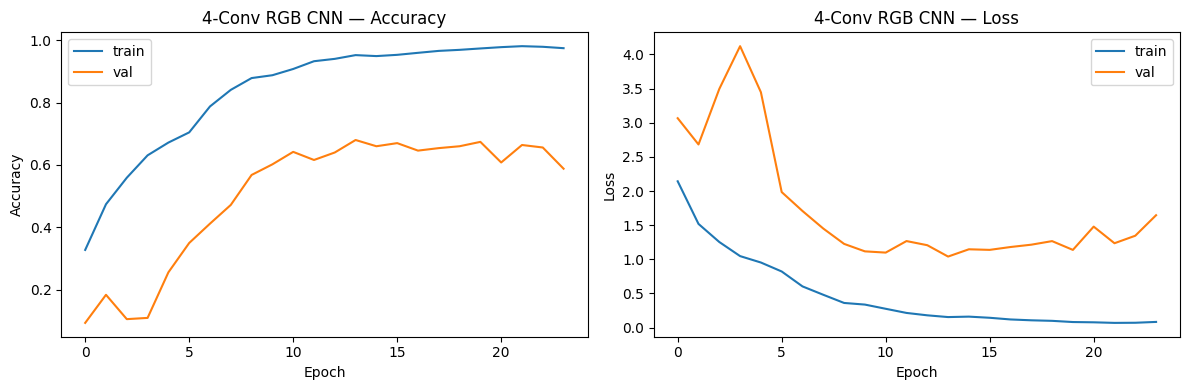

In [ ]:
# 4-conv variant (extra_conv=True adds Conv4 + MaxPool after Conv3)
cnn_rgb_4conv = build_cnn(input_shape=(32, 32, 3), extra_conv=True)
cnn_rgb_4conv.compile(
    optimizer=AdamW(learning_rate=0.001, weight_decay=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
cnn_rgb_4conv.summary()

history_rgb4 = cnn_rgb_4conv.fit(
    x_train_rgb_norm, y_train_ohe,
    batch_size=64,
    epochs=100,
    validation_split=0.1,
    class_weight=cnn_class_weight,
    callbacks=[EarlyStopping(
        monitor='val_loss', patience=10,
        restore_best_weights=True, verbose=1
    )],
    verbose=1
)

loss_rgb4, acc_rgb4 = cnn_rgb_4conv.evaluate(x_test_rgb_norm, y_test_ohe, verbose=0)
print(f'\n4-Conv RGB CNN — Test Loss    : {loss_rgb4:.4f}')
print(f'4-Conv RGB CNN — Test Accuracy: {acc_rgb4:.4f}')

print('\n--- Model Comparison ---')
print(f'Logistic Regression (grayscale): {test_acc:.4f}')
print(f'CNN 3-Conv (grayscale)          : {acc_gray:.4f}')
print(f'CNN 3-Conv (RGB)                : {acc_rgb:.4f}')
print(f'CNN 4-Conv (RGB)                : {acc_rgb4:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_rgb4.history['accuracy'],     label='train')
axes[0].plot(history_rgb4.history['val_accuracy'], label='val')
axes[0].set_title('4-Conv RGB CNN — Accuracy')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history_rgb4.history['loss'],     label='train')
axes[1].plot(history_rgb4.history['val_loss'], label='val')
axes[1].set_title('4-Conv RGB CNN — Loss')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

###10. Use the next markup to write down your observations and reasonings on the performances of the models

Logistic Regression (Grayscale): The Baseline
As expected, LR struggled the most. When you flatten an image into a simple 1024-dimensional list of gray pixels, you're asking a basic linear model to make sense of highly complex visual data. Plus, stripping away the color removes massive clues, like using the blue of the sky to spot an airplane or the green of a frog. It simply doesn't have the complexity to draw boundaries between these classes.

CNN 3-Conv (Grayscale) vs. Logistic Regression
Moving to a 3-layer CNN makes a night-and-day difference, even in black and white. Instead of looking at a flat list of pixels, the CNN actually "looks" at the image. Its earlier layers pick up on basic edges and textures, while deeper layers piece those together into recognizable shapes. Throw in Max Pooling, and the model doesn't just memorize where an object is. It can recognize a shape even if it shifts around, all while keeping the model from getting too bloated.

CNN 3-Conv (RGB) vs. CNN 3-Conv (Grayscale)
When we give the CNN its color vision back (RGB), performance jumps again. Color provides incredibly strong hints for a model. A frog is usually green; the sky behind a plane is blue. Without those color channels, the grayscale model has to work much harder to distinguish objects based purely on light and shadow.

CNN 4-Conv vs. CNN 3-Conv ( Both RGB)
You might assume that adding a fourth convolutional layer would make the model even smarter, but the returns actually diminish here. Because our starting images are so small (32x32), by the time they pass through multiple pooling layers, they get shrunk down to a tiny 4x4 grid. At that point, there's just not enough spatial detail left to extract meaningful features. Furthermore, since we're only working with 5,000 samples, making the model too deep just risks overfitting , where it starts memorizing the training data instead of actually learning. Thankfully, early stopping helps catch this before it gets too bad.

Across the board, the CNNs leaned heavily on a few best practices to stay on track. Batch Normalization helped keep the training process stable, while Dropout acted as a guardrail against overfitting. Using class weights ensured the models paid fair attention to every category, even if the data wasn't perfectly balanced. Finally, optimizing with AdamW did a great job of penalizing overly large weights, helping the models generalize much better to unseen data. So it overall performs better.